# Random Sampling Techniques and Estimation

## Question 1 Simple Random Sampling with and without Replacement

Consider the following finite population of size $N = 30$ representing a quantitative characteristic $Y$:
Y = \{12, 15, 18, 20, 22, 25, 27, 30, 32, 35,
     14, 16, 19, 21, 23, 26, 28, 31, 33, 36,
     13, 17, 24, 29, 34, 37, 38, 39, 40, 42\}


In [7]:
import numpy as np
import pandas as pd
Y=np.array([12, 15, 18, 20, 22, 25, 27, 30, 
            32, 35, 14, 16, 19, 21, 23, 26, 
            28, 31, 33, 36, 13, 17, 24, 29, 
            34, 37, 38, 39, 40, 42])
N=len(Y)

In [8]:
muY=np.mean(Y)
sig2Y=np.var(Y,ddof=0)
print(f"Population Mean: {muY:.4f} and Population Variance: {sig2Y:.4f}")

Population Mean: 26.5333 and Population Variance: 75.9156


In [9]:
np.random.seed(123)
sample_wr=np.random.choice(Y,8,replace=True)
Ybar_wr=np.mean(sample_wr)
Sig2_wr=np.var(sample_wr,ddof=1)
print(f"Sample Mean: {Ybar_wr:.4f} and Sample Variance: {Sig2_wr:.4f} for with replacement")

Sample Mean: 25.6250 and Sample Variance: 88.2679 for with replacement


In [10]:
np.random.seed(123)
sample_wor=np.random.choice(Y,8,replace=False)
Ybar_wor=np.mean(sample_wor)
Sig2_wor=np.var(sample_wor,ddof=1)
print(f"Sample Mean: {Ybar_wor:.4f} and Sample Variance: {Sig2_wor:.4f} for without replacement")

Sample Mean: 30.2500 and Sample Variance: 86.7857 for without replacement


In [13]:
VYbar_wr=[]
VYbar_wor=[]
for _ in range(1000):
    VYbar_wr.append(np.mean(np.random.choice(Y,8,replace=True)))
    VYbar_wor.append(np.mean(np.random.choice(Y,8,replace=False)))

In [19]:
pd.DataFrame({"Method":["SRSWR","SRSWOR"],
    "Means": [np.mean(VYbar_wr),np.mean(VYbar_wor)],
    "Var": [np.var(VYbar_wr),np.var(VYbar_wor)],
    "MSE": [np.mean((VYbar_wr-muY)**2),np.mean((VYbar_wor-muY)**2)]})

,Method,Means,Var,MSE
0,SRSWR,26.637375,9.609956,9.620781
1,SRSWOR,26.458750,7.145017,7.150580


<Axes: ylabel='Density'>

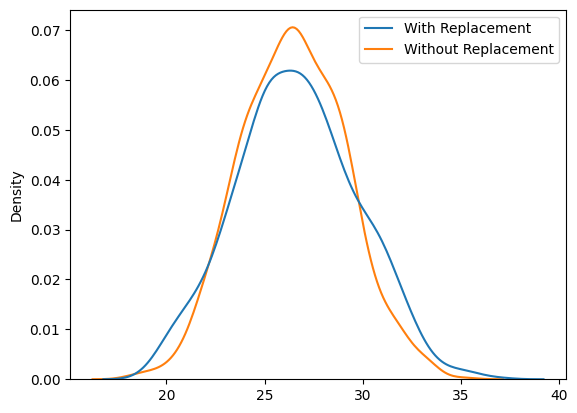

In [25]:
import seaborn as sns
sns.kdeplot(pd.DataFrame({"With Replacement":VYbar_wr,"Without Replacement":VYbar_wor}))